<a href="https://colab.research.google.com/github/maria-gigi/Research-Machine-Learning-2026/blob/main/Treino_Atividades.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler as ss
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import files

upload = files.upload()

Saving Tabela_REA_Hubs.csv to Tabela_REA_Hubs.csv


In [ ]:
data = pd.read_csv('Tabela_REA_Hubs.csv', sep = ";")
coluna_prever = "Atividade"
colunas_remover = [coluna_prever, "Sujeito"]

x_df = data.drop(columns = colunas_remover, errors = 'ignore')
x = x_df.values

print(f"Quantidade de atributos X: {x.shape[1]}")

Quantidade de atributos X: 116


In [ ]:
label = LabelEncoder()
y_df = label.fit_transform(data[coluna_prever])

print("Mapeamento das classes:", dict(zip(label.classes_, range(len(label.classes_)))))

Mapeamento das classes: {'AC': 0, 'AS': 1, 'BL': 2, 'EV': 3, 'RL': 4, 'T1': 5}


In [ ]:
sc = ss()
x = sc.fit_transform(x)

In [ ]:
x = torch.tensor(x, dtype = torch.float32)
y = torch.tensor(y_df, dtype = torch.long)

In [ ]:
class CustomDataset(Dataset):
  def __init__(self, x, y):
    self.x = x
    self.y = y

  def __getitem__(self, index):
    return self.x[index], self.y[index]

  def __len__(self):
    return len(self.x)

dataset = CustomDataset(x, y)
train_loader = DataLoader(dataset, batch_size = 4, shuffle = True)
print(f"\nTotal de batches no dataset: {len(train_loader)}")

for (batch_x, batch_y) in train_loader:
  print(f"Batch X: {batch_x.shape}")
  print(f"Batch Y: {batch_y.shape}")
  break


Total de batches no dataset: 13
Batch X: torch.Size([4, 116])
Batch Y: torch.Size([4])


In [ ]:
class Model(nn.Module):
  def __init__(self, input_features, output_features):
    super(Model, self).__init__()
    self.linear1 = nn.Linear(input_features, 32)
    self.linear2 = nn.Linear(32, 16)
    self.linear3 = nn.Linear(16, output_features)
    self.tanh = nn.Tanh()

  def forward(self,x):
    out = self.linear1(x)
    out = self.tanh(out)
    out = self.linear2(out)
    out = self.tanh(out)
    out = self.linear3(out)
    return out

In [ ]:
num_features_entrada = x.shape[1]
num_features_saida = len(label.classes_)

rede = Model(input_features = num_features_entrada, output_features = num_features_saida)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(rede.parameters(), lr = 0.01, momentum = 0.9, weight_decay=0.01)

In [ ]:
historico_loss = []
historico_accuracy = []

epochs = 50
for epoch in range(epochs):
  running_loss = 0.0
  correct_predictions = 0
  total_samples = 0

  for inputs, labels in train_loader:
    outputs = rede(inputs)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * inputs.size(0)

    _, predicted = torch.max(outputs, dim = 1)
    correct_predictions += (predicted == labels).sum().item()
    total_samples += labels.size(0)

  epoch_loss = running_loss / total_samples
  epoch_accuracy = correct_predictions / total_samples

  historico_loss.append(epoch_loss)
  historico_accuracy.append(epoch_accuracy)

  if (epoch + 1) % 5 == 0 or epoch == 0:
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

Epoch 1/50, Loss: 1.8037, Accuracy: 0.1346
Epoch 5/50, Loss: 1.4707, Accuracy: 0.4423
Epoch 10/50, Loss: 0.9825, Accuracy: 0.6731
Epoch 15/50, Loss: 0.7869, Accuracy: 0.7692
Epoch 20/50, Loss: 0.4172, Accuracy: 0.8846
Epoch 25/50, Loss: 0.3040, Accuracy: 0.9615
Epoch 30/50, Loss: 0.2432, Accuracy: 0.9615
Epoch 35/50, Loss: 0.1821, Accuracy: 0.9615
Epoch 40/50, Loss: 0.2528, Accuracy: 0.9423
Epoch 45/50, Loss: 0.1932, Accuracy: 0.9231
Epoch 50/50, Loss: 0.0674, Accuracy: 1.0000


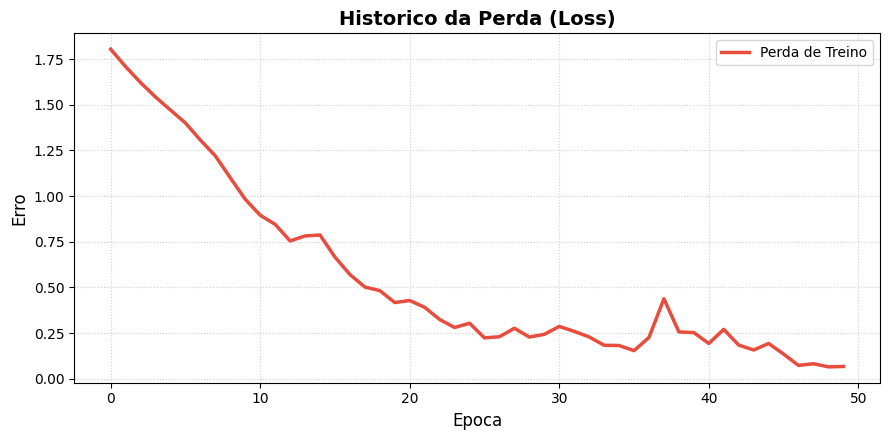

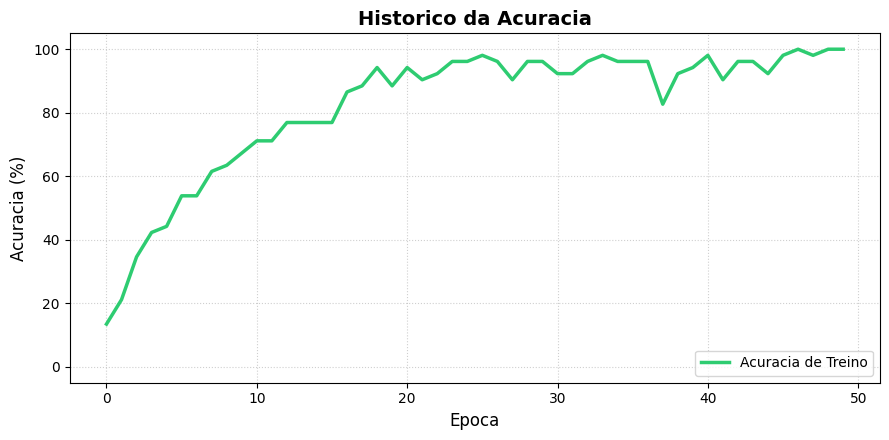

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4.5))
plt.plot(historico_loss, color='#e74c3c', linewidth=2.5, label='Perda de Treino')

plt.title('Historico da Perda (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Epoca', fontsize=12)
plt.ylabel('Erro', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.5))

plt.plot([acc * 100 for acc in historico_accuracy],
         color='#2ecc71',
         linewidth=2.5,
         label='Acuracia de Treino')

plt.title('Historico da Acuracia', fontsize=14, fontweight='bold')
plt.xlabel('Epoca', fontsize=12)
plt.ylabel('Acuracia (%)', fontsize=12)
plt.ylim(-5, 105) # Garante que o eixo Y vá de 0 a 100% com folga para o desenho
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()